In [1]:
from sklearn.datasets import fetch_openml
dataset = fetch_openml('mnist_784', version=1, as_frame=True)
df = dataset.frame
print(df)
df.shape

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
69995       0       0       0       0       0       0       0       0       0   
69996       0       0       0       0       0       0       0       0       0   
69997       0       0       0       0       0       0       0       0       0   
69998       0       0       0       0       0       0       0       0       0   
69999       0       0       0       0       0       0       0       0       0   

       pixel10  ...  pixel7

(70000, 785)

In [2]:
import sys
import os
sys.path.append(os.path.abspath('../../'))

In [3]:
from common.preprocessing_util import PreprocessingUtil as pp  

straigth_digits = {'1', '4', '7'}
curved_digits = {'0', '2', '3', '5', '6', '8', '9'}


df_bin = pp.binarize_labels(df, straigth_digits)

print(df_bin.shape)
print(df.shape)

hog_df = pp.hog_feature_extractor(df_bin)

print(hog_df.shape)


(70000, 785)
(70000, 785)
Extracting HOG features...
Extraction complete. New shape: (70000, 325)
(70000, 325)


In [4]:
import logistic_regression
x_train, y_train, x_test, y_test = pp.train_test_split(hog_df, 0.2) #test on 20% of data
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

import numpy as np
bias_train = np.ones((x_train.shape[0], 1))
bias_test = np.ones((x_test.shape[0], 1))
x_train_bias = np.hstack((bias_train, x_train)) # Stack the 1s onto the front of your X matrices
x_test_bias = np.hstack((bias_test, x_test))
num_weights = x_train_bias.shape[1]


(56000, 324) (56000,) (14000, 324) (14000,)


Training Started (Stochastic Gradient Descent)...
iteration 0 completed with errors: 6034
iteration 1 completed with errors: 3128
iteration 2 completed with errors: 2706
iteration 3 completed with errors: 2540
iteration 4 completed with errors: 2447
iteration 5 completed with errors: 2365
iteration 6 completed with errors: 2316
iteration 7 completed with errors: 2298
iteration 8 completed with errors: 2273
iteration 9 completed with errors: 2245
iteration 10 completed with errors: 2216
iteration 11 completed with errors: 2188
iteration 12 completed with errors: 2165
iteration 13 completed with errors: 2142
iteration 14 completed with errors: 2139
iteration 15 completed with errors: 2132
iteration 16 completed with errors: 2121
iteration 17 completed with errors: 2112
iteration 18 completed with errors: 2111
iteration 19 completed with errors: 2101
iteration 20 completed with errors: 2085
iteration 21 completed with errors: 2074
iteration 22 completed with errors: 2072
iteration 23 comp

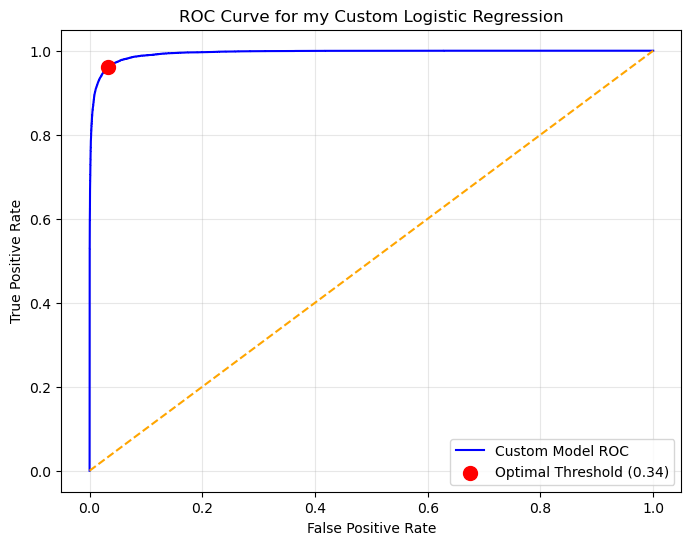

In [5]:
from logistic_regression import custom_logistic_regression

model = custom_logistic_regression(X=x_train_bias, Y=y_train, size=num_weights)
epochs, misclassifications = model.train_customized(_lambda_=0.001)

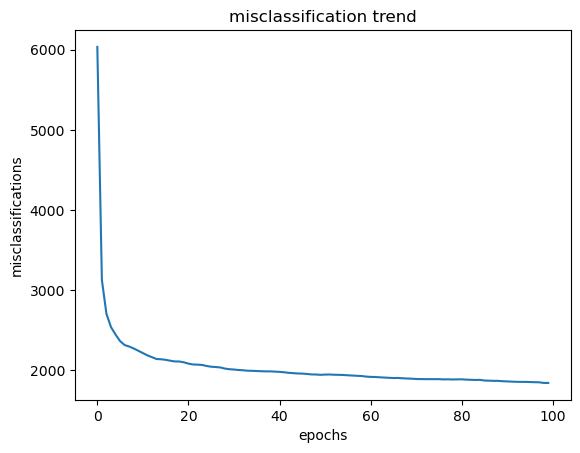

In [7]:
import matplotlib.pyplot as plt
plt.plot(epochs, misclassifications)
plt.xlabel('epochs')
plt.ylabel('misclassifications')
plt.title("misclassification trend")
plt.show()

In [ ]:
y_pred = model.predict_customized(x_test_bias)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score, f1_score

accuracy_of_custom = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_of_custom * 100:.2f}%\n")
precision_of_custom = precision_score(y_test,y_pred)
print(f"Precision: {precision_of_custom * 100:.2f}%\n")
recall_of_custom = recall_score(y_test,y_pred)
print(f"Recall: {recall_of_custom * 100:.2f}%\n")
f1_score_of_custom = f1_score(y_test,y_pred)
print(f"F1_score: {f1_score_of_custom * 100:.2f}%\n")

Accuracy: 97.03%

Precision: 94.40%

Recall: 96.32%

F1_score: 95.35%



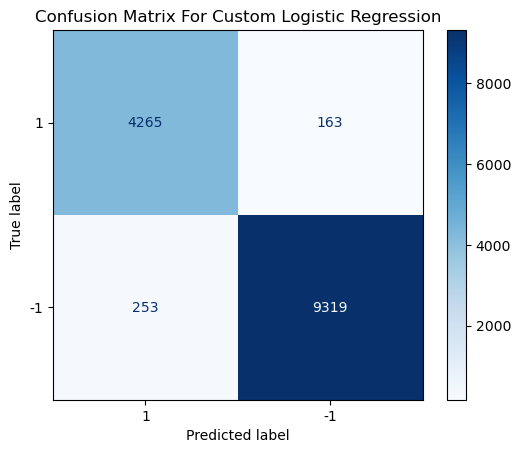

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

con_matrix = confusion_matrix(y_test, y_pred,labels=[1, -1])
con_disp = ConfusionMatrixDisplay(con_matrix,display_labels=[1, -1])
con_disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix For Custom Logistic Regression")
plt.show()


In [ ]:
#trying an already implemented model to see the difference in accuracy
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(max_iter=1000)
sklearn_model.fit(x_train, y_train)
sklearn_predictions = sklearn_model.predict(x_test)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-Learn Model: {sklearn_accuracy * 100:.2f}%")

Scikit-Learn Model: 97.66%
